## Probabilistic programming

- Using the computer for random experiments
- Very good for understanding
- Also used routinely when providing confidence intervals etc.
- The basis for any Monte-Carlo methods
- Important for any further statistical work including Bayesian data analysis

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt

## Normally distributed random numbers

- Use `np.random.normal`

In [33]:
x = np.random.normal(loc=0.0, scale=1.0, size=100000)

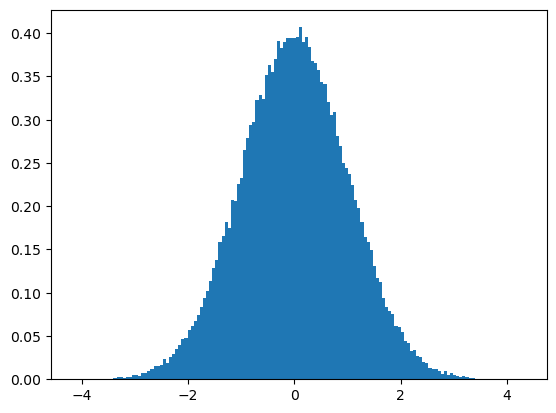

In [34]:
plt.hist(x, bins='auto', density=True);

## Using `scipy.stats`

- `np.random.xxx` provides random variates, or draws samples from a given
  distribution.
- `scipy.stats` provides a lot more conveniences.
- The [SciPy Stats
  reference](https://docs.scipy.org/doc/scipy/reference/stats.html) is worth
  checking out!
- The various distributions are objects which provide among other things:
  - `rvs()` - random variates
  - `pdf, cdf, mean, median, fit` etc.
  - `ppf` - inverse of the `cdf` etc.

This is very useful to understand a given distribution or use it for study.
Here is an example that we can study.

In [2]:
from scipy.stats import norm, binom, poisson
from ipywidgets import interact

In [ ]:
@interact( n=(1, 100), p=(0.01, 0.99))
def plot_binom(n, p):
    rv = binom(n, p)
    x = np.arange(0, n+1)
    plt.plot(x, rv.pmf(x), 'bo')
    plt.vlines(x, 0, rv.pmf(x), colors='b', alpha=0.5, lw=5)
    # Compare with a normal distribution
    mu, sigma = n*p, np.sqrt(n*p*(1-p))
    x1 = np.linspace(0, n+1)
    plt.plot(x1, norm.pdf(x1, loc=mu, scale=sigma), 'g--')

interactive(children=(IntSlider(value=50, description='n', min=1), FloatSlider(value=0.5, description='p', max…

Here is an example with a Poisson distribution.

In [5]:
@interact(lam=(0.0, 100))
def plot_poisson(lam=4):
    rv = poisson(lam)
    min, max = rv.ppf(0.0001), rv.ppf(0.9999999999)
    x = np.arange(min, max)
    plt.plot(x, norm.pdf(x, loc=lam, scale=np.sqrt(lam)), 'g--')
    plt.plot(x, rv.pmf(x), 'bo')
    plt.vlines(x, 0, rv.pmf(x), colors='b', alpha=0.5, lw=5)
    plt.xlim(0, 50)


interactive(children=(FloatSlider(value=4.0, description='lam'), Output()), _dom_classes=('widget-interact',))

Here is an example with a T distribution.

In [6]:
from scipy.stats import t

@interact(n=(1, 50))
def plot_t(n=1):
    rv = t(n)
    x = np.linspace(-5, 5, 200)
    #plt.figure(figsize=(20, 10))
    plt.plot(x, norm.pdf(x), 'g--')
    plt.plot(x, rv.pdf(x))

interactive(children=(IntSlider(value=1, description='n', max=50, min=1), Output()), _dom_classes=('widget-int…

## Why is this useful?

- Can understand and study these distributions.
- Allows you to construct experiments with random variables.
- Can numerically explore very interesting and important questions.
- Gateway to look at [Monte-Carlo methods](https://en.wikipedia.org/wiki/Monte_Carlo_method)!

- Such methods can defeat the curse of dimensionality!

Let us look at a few practical(?) examples. :)

### Volume estimation

- Calculate the area of a sphere in d dimensions.
- We consider a single quadrant, so in 2-D we multiply by $2^d$
- Throw uniformly distributed points and see which fall inside the sphere.


In [58]:
x = np.random.random((5, 2))
x

array([[0.06861267, 0.34718842],
       [0.57290604, 0.16195678],
       [0.90987058, 0.53906649],
       [0.68532195, 0.48493988],
       [0.60735377, 0.12593557]])

In [59]:
np.linalg.norm(x)

np.float64(1.6394289308086671)

In [60]:
np.linalg.norm(x, axis=1)

array([0.35390323, 0.59535816, 1.05757135, 0.83954325, 0.62027281])

In [61]:
np.linalg.norm(x, axis=1) < 1.0

array([ True,  True, False,  True,  True])

In [62]:
n = 100000
(np.linalg.norm(np.random.random((n, 2)), axis=1) < 1).sum()/n*2**2

np.float64(3.13932)


- This will work as you increase the number of dimensions.
- Impossibly hard to do with normal numerical integration.

### Statistical computations

- Given Sachin's (or Virat Kohli's if you prefer) scores in our `data/`
  directory.
- Let us say he is going to play in a ODI series of 5 games.
- Estimate what you think he will score on average with an 80% confidence
  interval.

100000


array([24.6, 74.4])

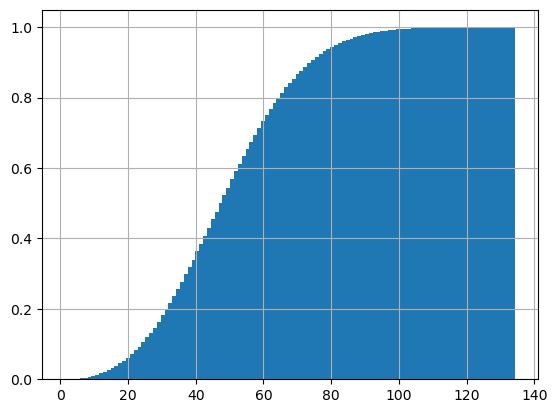

In [39]:
# Live solution and discussion.
kohli=np.loadtxt('../data/kohli.txt')
kohliAvg = np.mean(kohli)

trials=100000
samplingAvgOf5Matches = []

for i in range(trials):
    samplingAvgOf5Matches.append(np.mean(np.random.choice(kohli,size=5)))

print(len(samplingAvgOf5Matches))

plt.hist(samplingAvgOf5Matches,bins='auto', density=True, cumulative=True)
plt.grid()
np.percentile(samplingAvgOf5Matches,[10,90])


As you can see we can answer some profound practical questions using this
sort of approach.